In [18]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.fft as fft
import seaborn as sns
import torch
from scipy.stats import genextreme, genpareto, pareto
import importlib
import wxderivs
importlib.reload(wxderivs)

from wxderivs import (
    DIR_WORK,
    MONTH_CDD,
    MONTH_HDD,
    SET_TARGET_US_CITIES,
    SET_CDD,
    SET_HDD,
    SET_USA,
    dct_name_file,
    fit_mean_std,
)



sys.path.append(str(DIR_WORK / "unibm"))

import unibm
import unibm.benchmark


0 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Essen.csv
1 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Boston.csv
2 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Philadelphia.csv
3 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/NewYork.csv
4 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Burbank.csv
5 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/London.csv
6 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Dallas.csv
7 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Paris.csv
8 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Portland.csv
9 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/tempe

In [19]:
df_max_all = {}
df_min_all = {}

for name in SET_USA:
    tmp_df = pd.read_csv(dct_name_file[name])
    tmp_df.index = pd.to_datetime(tmp_df["DATE"])
    df_max_all[name] = tmp_df["DAILY_MAX_TEMP"]
    df_min_all[name] = tmp_df["DAILY_MIN_TEMP"]
df_max_all = pd.DataFrame(df_max_all)
df_min_all = pd.DataFrame(df_min_all)
df_avg_all = (df_max_all + df_min_all) / 2
df_y = df_avg_all
df_max_all.head()

,Atlanta,Minneapolis,Burbank,Dallas,Boston,Sacramento,Houston,Cincinnati,Portland,Chicago,LasVegas,Philadelphia,NewYork
DATE,,,,,,,,,,,,,
2005-01-01,69.0,28.0,54.0,74.0,52.0,54.0,75.0,54.0,43.0,41.0,56.0,64.0,58.0
2005-01-02,68.0,28.0,58.0,68.0,40.0,48.0,73.0,58.0,45.0,54.0,52.0,47.0,48.0
2005-01-03,68.0,16.0,53.0,76.0,53.0,49.0,79.0,59.0,43.0,36.0,47.0,57.0,56.0
2005-01-04,71.0,16.0,51.0,70.0,45.0,49.0,73.0,58.0,40.0,35.0,53.0,55.0,49.0
2005-01-05,68.0,9.0,55.0,68.0,40.0,50.0,77.0,46.0,41.0,31.0,50.0,47.0,45.0


In [20]:
def plot_day_of_year(
    srs,
    is_day_of_year_frac=False,
    is_scatter=False,
    alpha=0.7,
    is_label=False,
    xlabel="Day of year",
    ylabel="Temperature",
    title="Temperature vs Day of year",
    axhline=[
        65,
    ],
    axvline_red=pd.DatetimeIndex(["2020-05-01", "2020-09-30"]).day_of_year.to_list(),
    axvline_blue=pd.DatetimeIndex(["2020-11-01", "2020-03-31"]).day_of_year.to_list(),
    ax=None,
):
    if is_day_of_year_frac:
        vec_t = (srs.index.day_of_year / (srs.index.is_leap_year + 365)).to_numpy()
    else:
        vec_t = srs.index.day_of_year.to_numpy()
    vec_y = srs.to_numpy()
    year_unique = srs.index.year.unique()
    cmap = plt.get_cmap("rainbow", len(year_unique))
    color_map = {year: cmap(i) for i, year in enumerate(year_unique)}
    if ax is None:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    for year in year_unique:
        idx = srs.index.year == year
        if is_scatter:
            ax.scatter(
                vec_t[idx],
                vec_y[idx],
                s=1,
                color=color_map[year],
                alpha=alpha,
                label=year if is_label else None,
            )
        else:
            ax.plot(
                vec_t[idx],
                vec_y[idx],
                label=year,
                alpha=alpha,
                lw=1,
                c=color_map[year],
                linestyle="-.",
            )
    if axhline:
        for _ in axhline:
            ax.axhline(_, color="black", linestyle="--", lw=0.9)
    if axvline_red:
        for _ in axvline_red:
            ax.axvline(_, color="red", linestyle="--", lw=0.9)
    if axvline_blue:
        for _ in axvline_blue:
            ax.axvline(_, color="blue", linestyle="--", lw=0.9)
    ax.grid()
    if is_label:
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

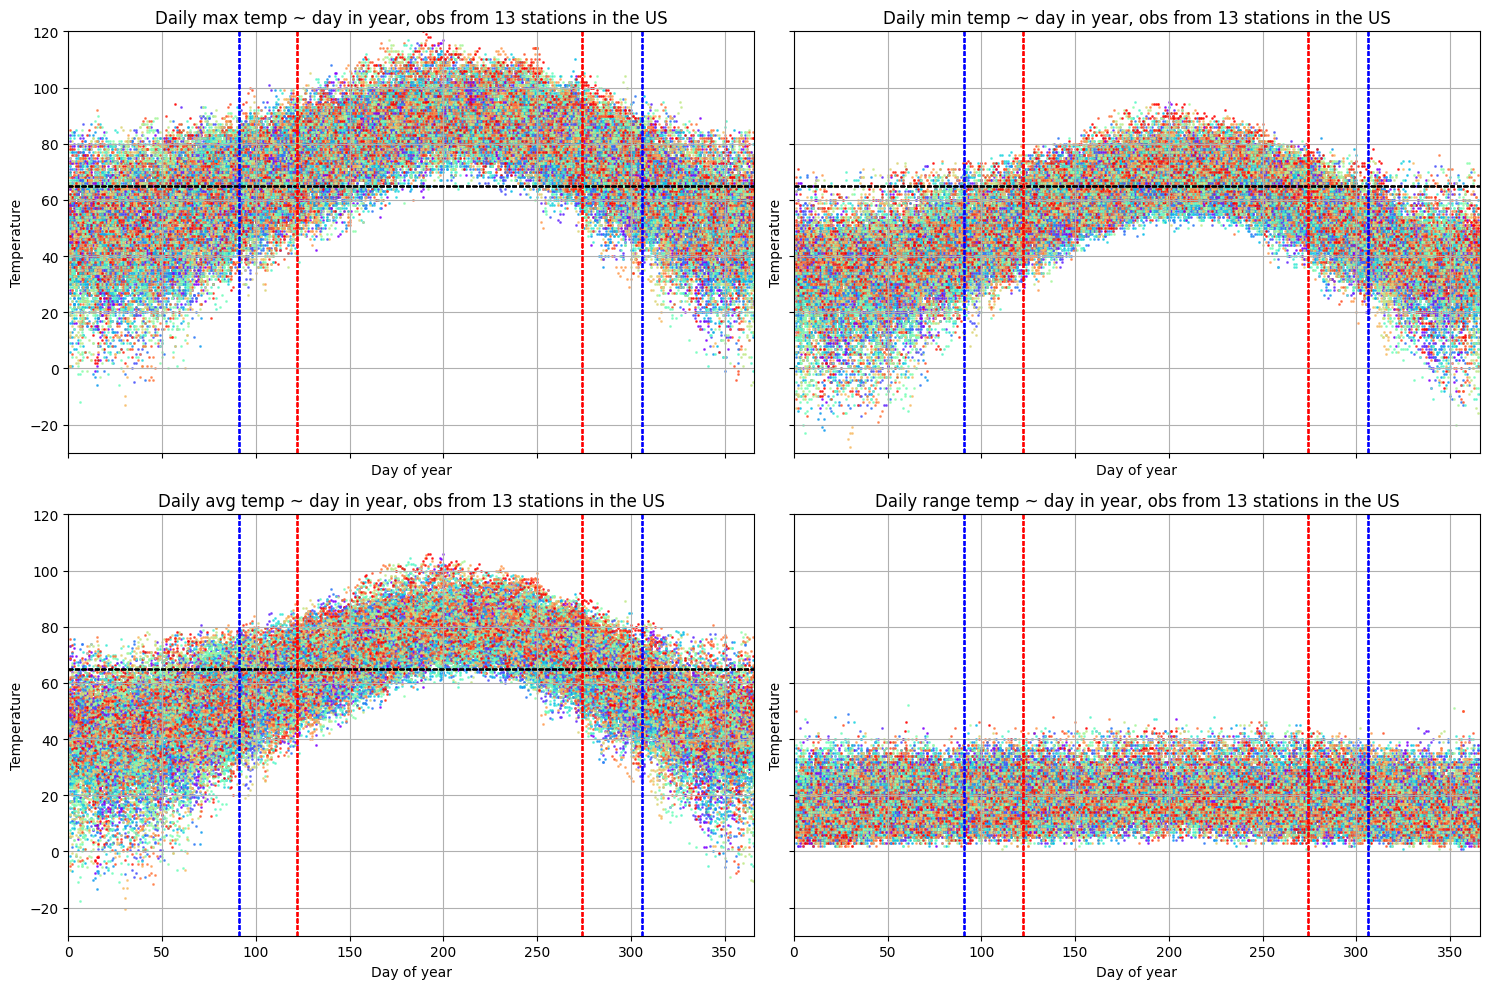

In [21]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True, sharey=True)
for station in SET_USA:
    plot_day_of_year(
        df_max_all[station],
        is_scatter=True,
        title="Daily max temp ~ day in year, obs from 13 stations in the US",
        ax=axes[0, 0],
    )
    plot_day_of_year(
        df_min_all[station],
        is_scatter=True,
        title="Daily min temp ~ day in year, obs from 13 stations in the US",
        ax=axes[0, 1],
    )
    plot_day_of_year(
        (df_max_all[station] + df_min_all[station]) / 2,
        is_scatter=True,
        title="Daily avg temp ~ day in year, obs from 13 stations in the US",
        ax=axes[1, 0],
    )
    plot_day_of_year(
        df_max_all[station] - df_min_all[station],
        is_scatter=True,
        title="Daily range temp ~ day in year, obs from 13 stations in the US",
        ax=axes[1, 1],
        axhline=None,
    )
for ax in axes.flatten():
    ax.set_xlim(0, 366)
    ax.set_ylim(-30, 120)
plt.tight_layout()

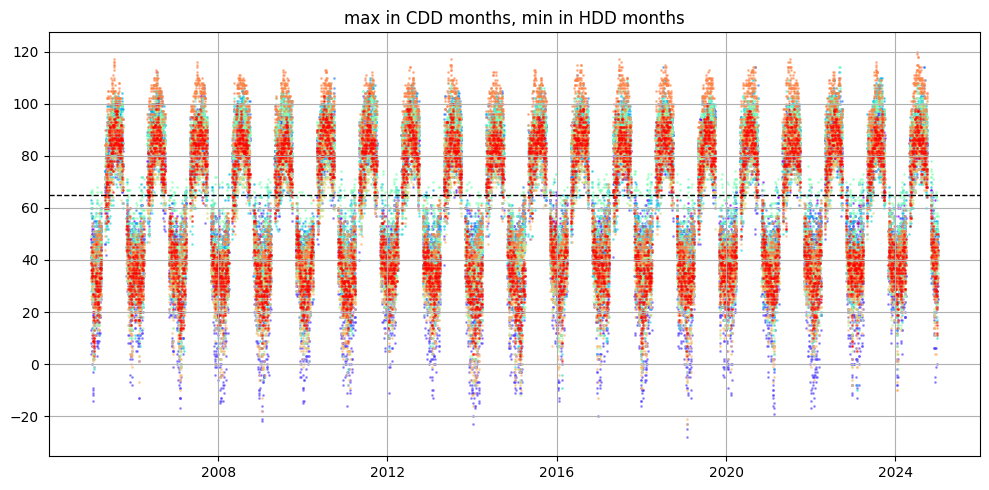

In [22]:
cmap = plt.get_cmap("rainbow", len(SET_USA))
color_map = {year: cmap(i) for i, year in enumerate(SET_USA)}
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
for station in SET_USA:
    idx = df_max_all.index.month.isin(MONTH_CDD)
    ax.scatter(
        df_max_all[idx].index,
        df_max_all[idx][station],
        s=1,
        alpha=0.5,
        color=color_map[station],
        label=f"max, CDD months, {station}",
    )
    idx = df_min_all.index.month.isin(MONTH_HDD)
    ax.scatter(
        df_min_all[idx].index,
        df_min_all[idx][station],
        s=1,
        alpha=0.5,
        color=color_map[station],
        label=f"min, HDD months, {station}",
    )
plt.axhline(65, color="black", linestyle="--", lw=1)
plt.title("max in CDD months, min in HDD months")
# plt.legend()
plt.grid()
plt.tight_layout()

In [23]:
dct_fit_res = {}
for station in SET_TARGET_US_CITIES:
    dct_fit_res[station] = fit_mean_std(
        srs=(df_max_all[station] + df_min_all[station]) / 2
    )

/workspaces/Financial-Engineering-Project/notebooks/wxderivs/__init__.py:126: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  + alpha * vec_res[i - 1] ** 2
/workspaces/Financial-Engineering-Project/notebooks/wxderivs/__init__.py:127: RuntimeWarning: overflow encountered in scalar power
  + beta * vec_variance[i - 1] ** 2
/workspaces/Financial-Engineering-Project/notebooks/wxderivs/__init__.py:126: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  + alpha * vec_res[i - 1] ** 2
/workspaces/Financial-Engineering-Project/notebooks/wxderivs/__init__.py:127: RuntimeWarning: overflow encountered in scalar power
  + beta * vec_var

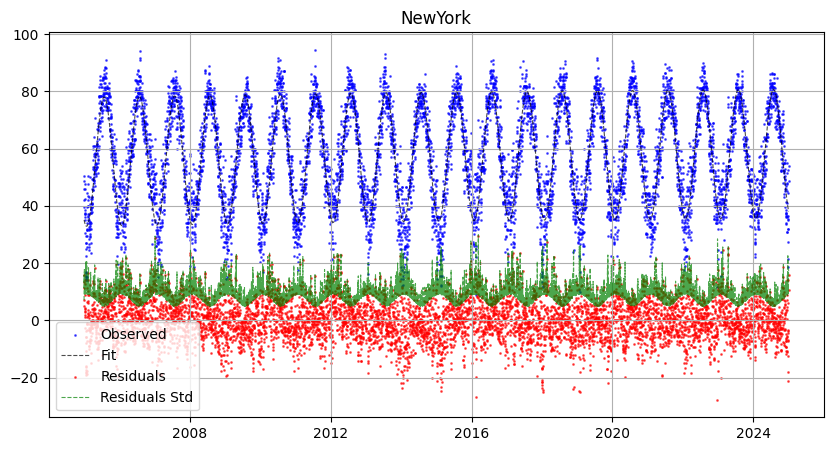

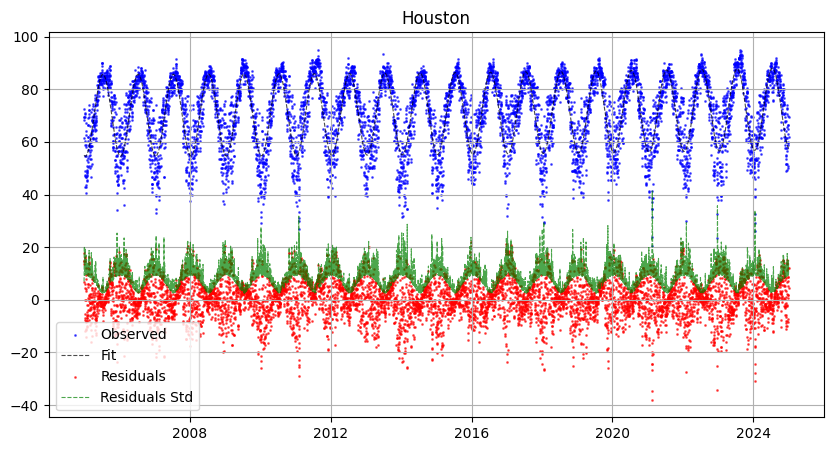

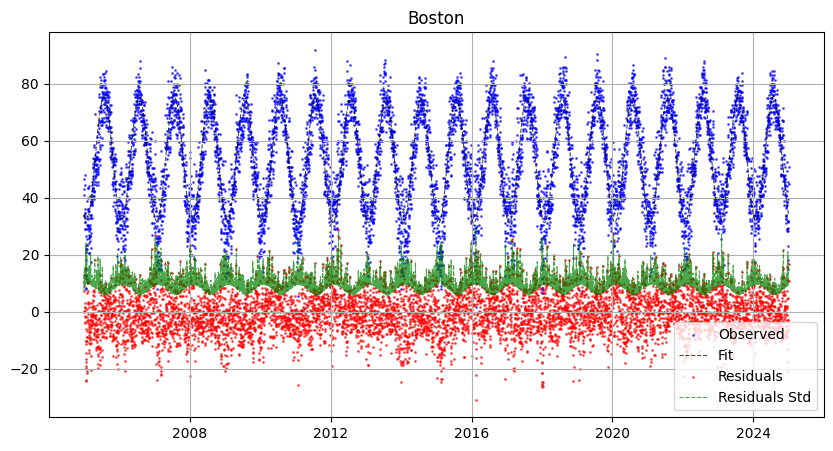

In [25]:
for station in SET_TARGET_US_CITIES:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    ax.set_title(f"{station}")
    ax.scatter(
        x=dct_fit_res[station]["vec_index"],
        y=dct_fit_res[station]["vec_y"],
        s=1,
        color="blue",
        alpha=0.6,
        label="Observed",
    )
    ax.plot(
        dct_fit_res[station]["vec_index"],
        dct_fit_res[station]["vec_y_pred"],
        linewidth=0.8,
        alpha=0.7,
        label="Fit",
        color="black",
        linestyle="--",
    )
    ax.scatter(
        x=dct_fit_res[station]["vec_index"],
        y=dct_fit_res[station]["vec_res"],
        s=1,
        color="red",
        alpha=0.6,
        label="Residuals",
    )
    ax.plot(
        dct_fit_res[station]["vec_index"],
        dct_fit_res[station]["vec_std"],
        linewidth=0.8,
        alpha=0.7,
        label="Residuals Std",
        color="green",
        linestyle="--",
    )
    ax.grid(True)
    ax.legend()
    
    if station == "NewYork":
        plt.savefig("New_York.svg", format='svg')

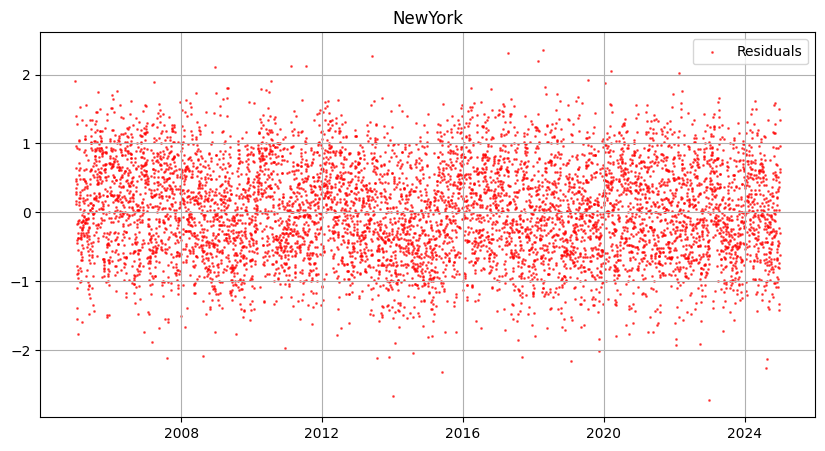

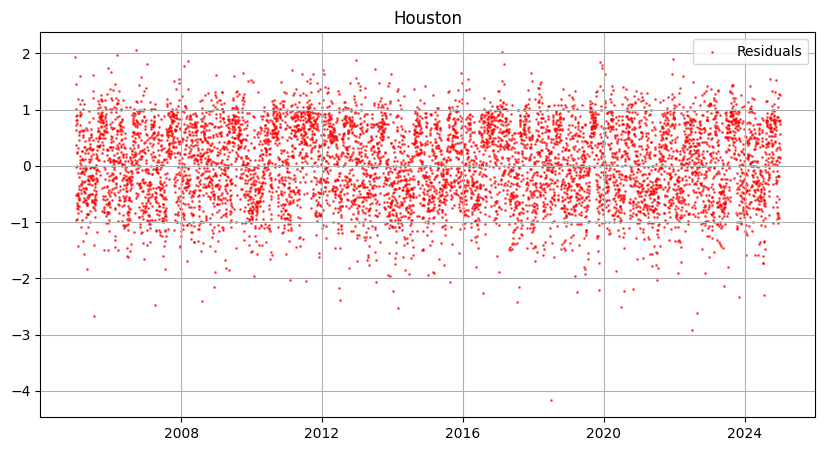

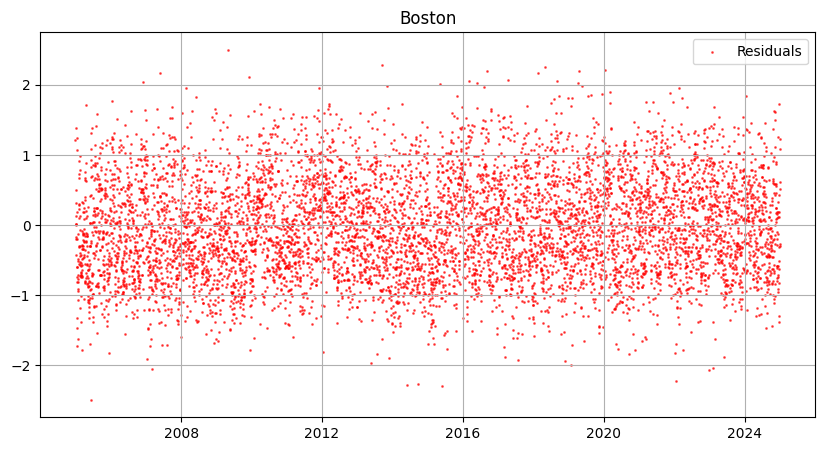

In [26]:
for station in SET_TARGET_US_CITIES:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    ax.set_title(f"{station}")
    ax.scatter(
        x=dct_fit_res[station]["vec_index"],
        y=dct_fit_res[station]["vec_res_scaled"],
        s=1,
        color="red",
        alpha=0.6,
        label="Residuals",
    )
    ax.grid(True)
    ax.legend()

,intercept,slope,quadratic,amplitude_1,phase_1,amplitude_2,phase_2,amplitude_3,phase_3,amplitude_4,phase_4,omega,alpha,beta
count,3.000000,3.000000,3.000000e+00,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000e+00,3.000000,3.000000,3.000000,3.000000,3.000000e+00
mean,59.919106,-0.000142,5.480414e-08,-8.982998,0.190572,-11.121776,0.935200,6.450672,2.278910e-01,12.430490,0.479514,53.345335,0.929272,5.374495e-05
std,9.706622,0.000282,3.445204e-08,3.156551,0.010931,0.362763,0.016354,14.166190,3.647004e-01,28.372205,0.498081,8.814756,0.082843,9.308881e-05
min,51.944425,-0.000321,1.581859e-08,-10.836906,0.179789,-11.493163,0.919782,-9.366142,7.699329e-12,-19.518114,0.007362,45.062733,0.838058,1.000000e-10
25%,54.515089,-0.000304,4.162854e-08,-10.805343,0.185035,-11.298513,0.926624,0.690075,1.757577e-02,1.302994,0.219271,48.713005,0.893988,1.000001e-10
50%,57.085753,-0.000287,6.743848e-08,-10.773780,0.190281,-11.103864,0.933465,10.746293,3.515154e-02,22.124101,0.431181,52.363276,0.949918,1.000001e-10
75%,63.906446,-0.000052,7.429692e-08,-8.056045,0.195963,-10.936082,0.942909,14.359079,3.418365e-01,28.404792,0.715590,57.486636,0.974878,8.061738e-05
max,70.727140,0.000183,8.115535e-08,-5.338309,0.201645,-10.768301,0.952353,17.971866,6.485214e-01,34.685482,1.000000,62.609995,0.999839,1.612347e-04


array([[<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'quadratic'}>,
        <Axes: title={'center': 'amplitude_1'}>],
       [<Axes: title={'center': 'phase_1'}>,
        <Axes: title={'center': 'amplitude_2'}>,
        <Axes: title={'center': 'phase_2'}>,
        <Axes: title={'center': 'amplitude_3'}>],
       [<Axes: title={'center': 'phase_3'}>,
        <Axes: title={'center': 'amplitude_4'}>,
        <Axes: title={'center': 'phase_4'}>,
        <Axes: title={'center': 'omega'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'beta'}>, <Axes: >, <Axes: >]],
      dtype=object)

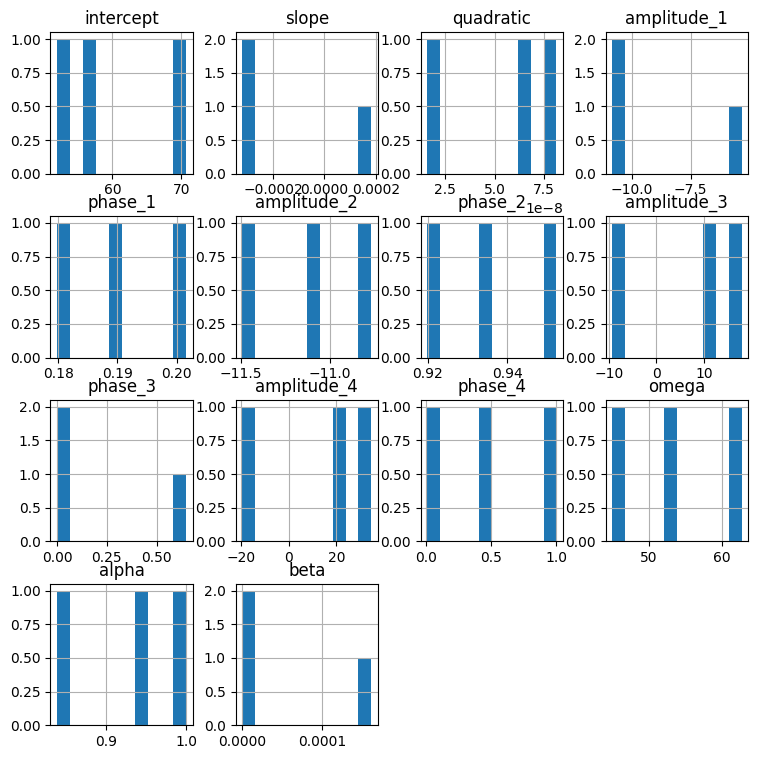

In [27]:
tmp_df = pd.DataFrame(
    {
        station: np.concat(
            [dct_fit_res[station]["fit_mean"].x, dct_fit_res[station]["fit_sgarch"].x]
        )
        for station in SET_TARGET_US_CITIES
    },
    index=[
        "intercept",
        "slope",
        "quadratic",
        "amplitude_1",
        "phase_1",
        "amplitude_2",
        "phase_2",
        "amplitude_3",
        "phase_3",
        "amplitude_4",
        "phase_4",
        "omega",
        "alpha",
        "beta",
    ],
).T
display(tmp_df.describe())
tmp_df.hist(figsize=(9, 9))

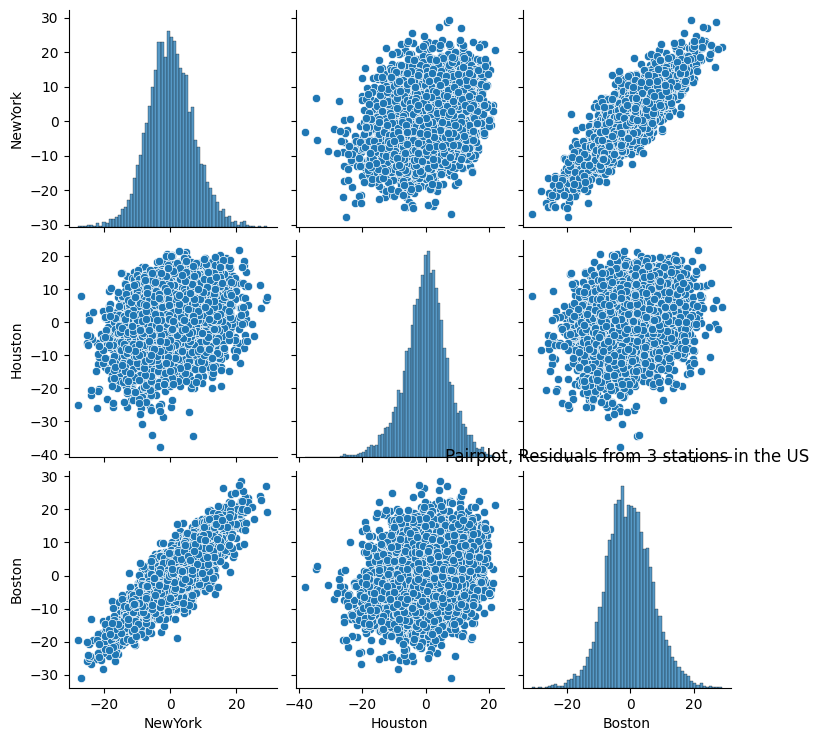

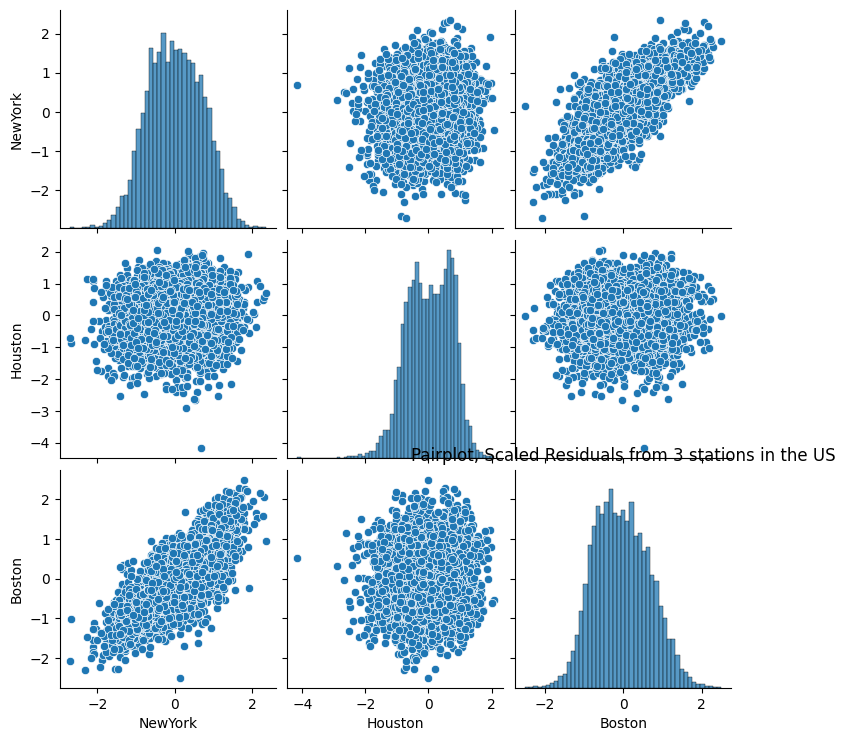

In [30]:

#
df_res = pd.DataFrame(
    {station: dct_fit_res[station]["vec_res"].values for station in SET_TARGET_US_CITIES},
    index=dct_fit_res[station]["vec_index"],
)
sns.pairplot(df_res)
plt.title("Pairplot, Residuals from 3 stations in the US")
#
df_res_scaled = pd.DataFrame(
    {station: dct_fit_res[station]["vec_res_scaled"].values for station in SET_TARGET_US_CITIES},
    index=dct_fit_res[station]["vec_index"],
)
sns.pairplot(df_res_scaled)
plt.title("Pairplot, Scaled Residuals from 3 stations in the US")
#
df_std = pd.DataFrame(
    {station: dct_fit_res[station]["vec_std"] for station in SET_TARGET_US_CITIES},
    index=dct_fit_res[station]["vec_index"],
)
df_y_pred = pd.DataFrame(
    {station: dct_fit_res[station]["vec_y_pred"] for station in SET_TARGET_US_CITIES},
    index=dct_fit_res[station]["vec_index"],
)

Text(0.5, 1.0, "Kendall's tau, Residuals from 3 stations in the US")

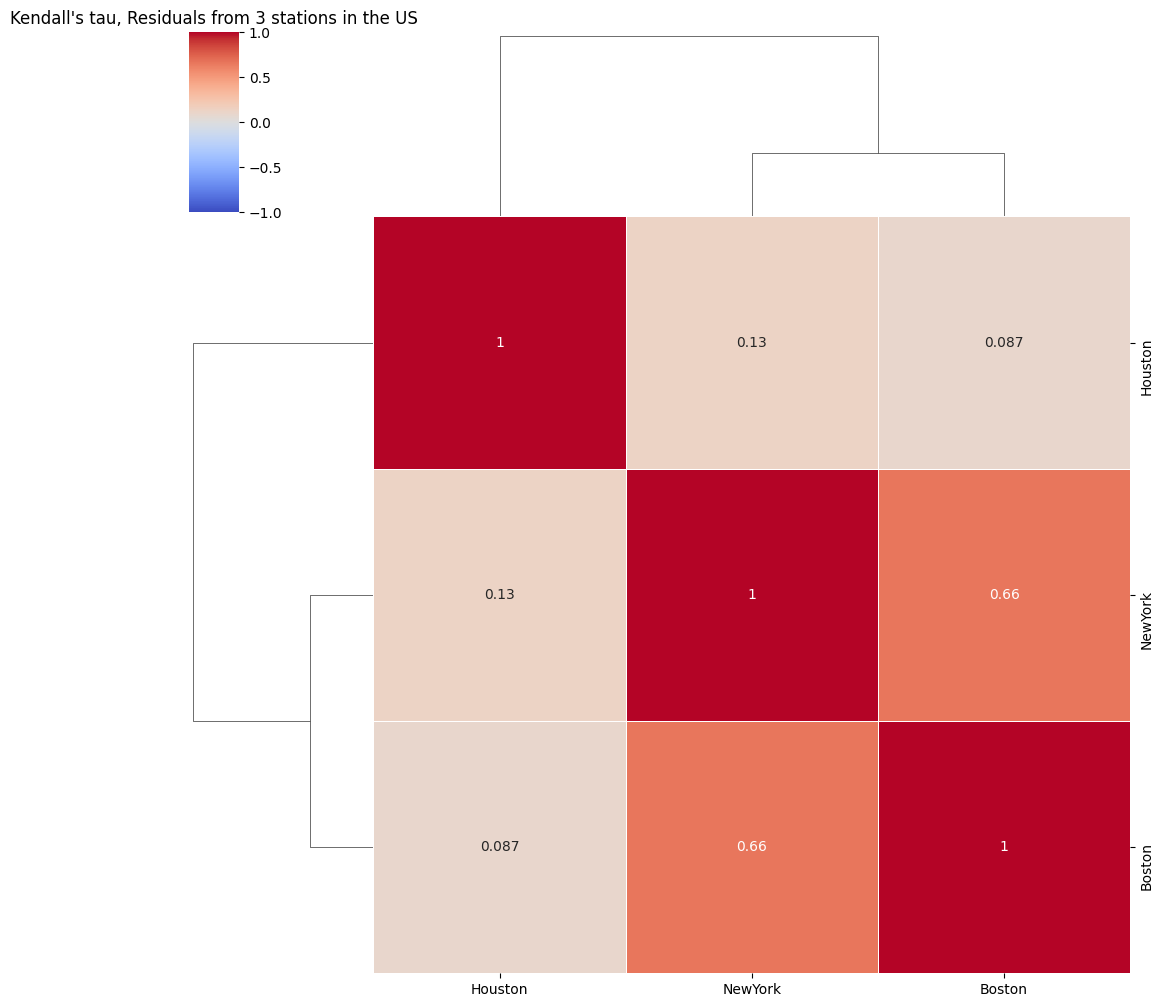

In [31]:
sns.clustermap(
    df_res.corr(method="kendall"),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Kendall's tau, Residuals from 3 stations in the US")

In [32]:
dct_evi_res_right = {}
for station in SET_TARGET_US_CITIES:
    tmp_vec = df_res[station].values
    tmp_vec = tmp_vec[tmp_vec > 0]
    dct_evi_res_right[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(tmp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(tmp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(tmp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(tmp_vec)
        ),
        "genextreme": genextreme.fit(tmp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(tmp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(tmp_vec, floc=0)[0].item(),
        # ! is_frechet=False
        "mpmr_wls": unibm.est_extreme_value_index(tmp_vec, is_frechet=False)[
            "slope_emr"
        ],
    }

In [33]:
df_evi_res_right = pd.DataFrame(dct_evi_res_right).head(7)
df_evi_res_right[df_evi_res_right < 0] = np.abs(df_evi_res_right[df_evi_res_right < 0])
df_evi_res_right[np.isinf(df_evi_res_right)] = np.nan
display(df_evi_res_right)
df_evi_res_right.median(axis=0)

,NewYork,Houston,Boston
hill,1.165944,0.556155,1.670908
schultze_steinebach,0.305178,0.303189,0.309903
smith,0.194000,0.152961,0.172466
meerschaert_scheffler,0.684565,0.672460,0.688463
genextreme,0.100945,0.108554,0.108778
genpareto,0.211706,0.258044,0.225237
pareto,0.137692,0.149770,0.088307


NewYork    0.211706
Houston    0.258044
Boston     0.225237
dtype: float64

In [34]:
dct_evi_res_left = {}
for station in SET_TARGET_US_CITIES:
    tmp_vec = df_res[station].values
    tmp_vec = -tmp_vec[tmp_vec < 0]
    dct_evi_res_left[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(tmp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(tmp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(tmp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(tmp_vec)
        ),
        "genextreme": genextreme.fit(tmp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(tmp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(tmp_vec, floc=0)[0].item(),
        # ! is_frechet=False
        "mpmr_wls": unibm.est_extreme_value_index(tmp_vec, is_frechet=False)[
            "slope_emr"
        ],
    }

In [35]:
df_evi_res_left = pd.DataFrame(dct_evi_res_left).head(7)
df_evi_res_left[df_evi_res_left < 0] = np.abs(df_evi_res_left[df_evi_res_left < 0])
df_evi_res_left[np.isinf(df_evi_res_left)] = np.nan
display(df_evi_res_left)
df_evi_res_left.median(axis=0)

,NewYork,Houston,Boston
hill,1.445448,0.376967,0.459434
schultze_steinebach,0.277413,0.267948,0.299572
smith,0.208551,0.233914,0.207199
meerschaert_scheffler,0.675400,0.693545,0.679608
genextreme,0.098926,0.006547,0.126015
genpareto,0.205051,0.121871,0.216097
pareto,0.154010,0.114316,0.121494


NewYork    0.208551
Houston    0.233914
Boston     0.216097
dtype: float64

In [ ]:
df_avg_all_target = df_avg_all[list(SET_TARGET_US_CITIES)]

df_cdd = (df_avg_all_target[df_avg_all_target.index.month.isin(MONTH_CDD)] - 65).clip(lower=0)
df_cdd.describe()

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (231211012.py, line 1)

In [ ]:
sns.pairplot(df_cdd)
plt.title("Pairplot, CDD from 3 stations in the US")